In [1]:
from eoutils import S1Processor
import glob

zips = glob.glob('/dmidata/projects/asip/sentinel1/arctic/S1*_EW_*.zip')

In [2]:
import torch

HH, HV = S1Processor(zips[0]).process(calib='sigma', remove_thermal_noise=True)

# I prefer to work with torch.tensor rather than numpy arrays when preparing data for the UNet model, since we have to convert to torch.tensor before training anyways
HH, HV = torch.tensor(HH), torch.tensor(HV)

[INFO: 2026-05-20 13:01:22: eoutils.S1Processor] Processesing started for S1D_EW_GRDM_1SDH_20260516T152527_20260516T152627_002811_004C50_60CC.SAFE.zip
[INFO: 2026-05-20 13:01:22: eoutils.S1Processor] Processing band 1/2: HH
[INFO: 2026-05-20 13:01:26: eoutils.S1Processor] Calibration and thermal noise removal...
[INFO: 2026-05-20 13:01:29: eoutils.S1Processor] Converting to dB...
[INFO: 2026-05-20 13:01:29: eoutils.S1Processor] Processing band 2/2: HV
[INFO: 2026-05-20 13:01:32: eoutils.S1Processor] Calibration and thermal noise removal...
[INFO: 2026-05-20 13:01:36: eoutils.S1Processor] Converting to dB...
[INFO: 2026-05-20 13:01:37: eoutils.S1Processor] Processing finished in 14.21s.


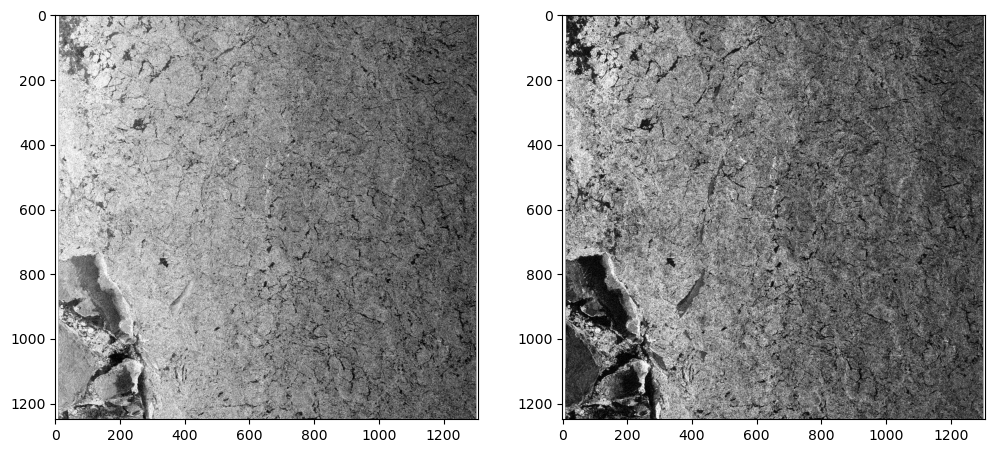

In [3]:
import matplotlib.pyplot as plt
import numpy as np

skip = 8
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(HH[::skip, ::skip], cmap='gist_gray', vmin=np.nanpercentile(HH, 2), vmax=np.nanpercentile(HH, 98))
ax[1].imshow(HV[::skip, ::skip], cmap='gist_gray', vmin=np.nanpercentile(HV, 2), vmax=np.nanpercentile(HV, 98))

In [4]:
# Functions for padding and sliding window ("patchify")

def compute_padded_shape(shape, patch_size, step_size):
    if step_size <= patch_size//2:
        print('Step_size must be larger than patch_size//2')
        raise NotImplementedError
    
    n0 = 0
    while n0*step_size + patch_size < shape[0]:
        n0 += 1

    n1 = 0
    while n1*step_size + patch_size < shape[1]:
        n1 += 1

    return ((n0+1)*step_size + patch_size, (n1+1)*step_size + patch_size)

def pad(arr, padded_shape, mode='constant', pad_value=255):
    import torch
    from math import ceil

    if len(arr.shape) == 2:
        arr = arr.unsqueeze(dim=0)

    horizontal_pad = padded_shape[1] - arr.shape[2] 
    vertical_pad = padded_shape[0] - arr.shape[1] 
        
    top = ceil(vertical_pad/2)
    bottom = vertical_pad//2
    left = ceil(horizontal_pad/2)
    right = horizontal_pad//2

    return torch.nn.functional.pad(arr, (left, right, top, bottom), mode=mode, value=pad_value if mode == 'constant' else None).squeeze(), (top, bottom, left, right)

def patchify(img, patch_size, step_size):
    """
    Patchifies single-channel (HxW) or multi-channel (CxHxW) images represented by tensors.
    Returns a list a ndarray patches.
    """
    
    if len(img.shape) == 2:
        img = img.unsqueeze(dim=0)
    
    patches = []
    for i in range(int(img.shape[-2]/step_size)):
        for j in range(int(img.shape[-1]/step_size)):
            patch = img[:, i*step_size:i*step_size + patch_size, j*step_size:j*step_size + patch_size]
            patches.append(patch.squeeze())
            
    return patches

In [5]:
shape = HH.shape
patch_size = 1024
overlap = 0.25 # 25% overlap between windows
step_size = int(patch_size*(1-overlap))

padded_shape = compute_padded_shape(shape=shape, patch_size=patch_size, step_size=step_size)
HH, _ = pad(HH, padded_shape=padded_shape, pad_value=np.nan) # padding with NaNs
HV, _ = pad(HV, padded_shape=padded_shape, pad_value=np.nan)

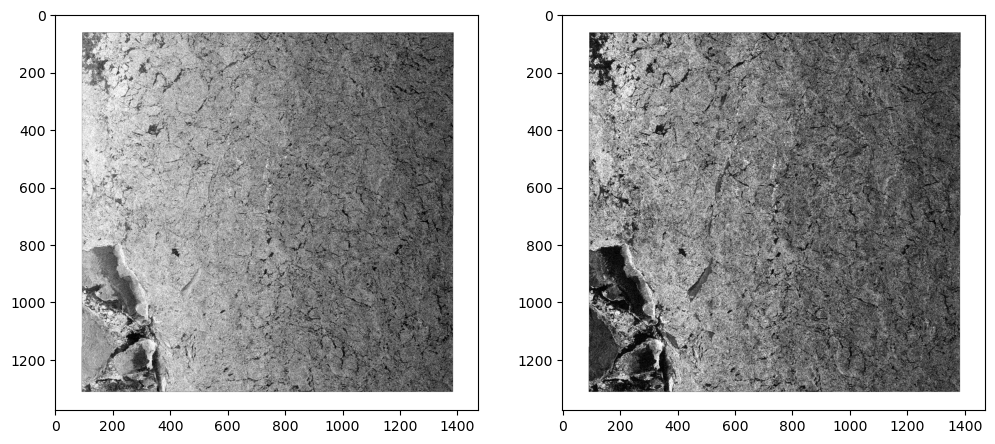

In [6]:
import matplotlib.pyplot as plt
import numpy as np

skip = 8
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(HH[::skip, ::skip], cmap='gist_gray', vmin=np.nanpercentile(HH, 2), vmax=np.nanpercentile(HH, 98))
ax[1].imshow(HV[::skip, ::skip], cmap='gist_gray', vmin=np.nanpercentile(HV, 2), vmax=np.nanpercentile(HV, 98))

In [7]:
HH_patches = patchify(HH, patch_size=patch_size, step_size=step_size)

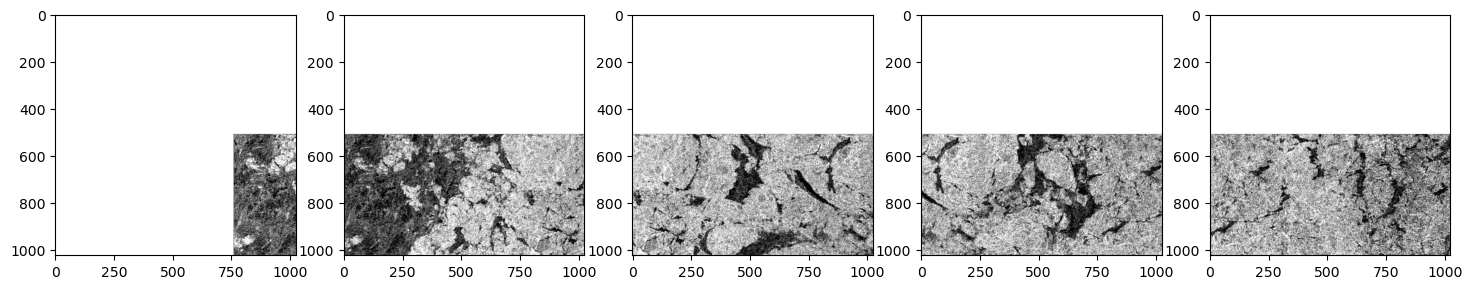

In [8]:
# Plotting the first few windows / patches from the top left corner

import matplotlib.pyplot as plt
import numpy as np

n = 5

fig, ax = plt.subplots(1, n, figsize=(18, 6))

for i in range(n):
    ax[i].imshow(HH_patches[i], cmap='gist_gray', vmin=np.nanpercentile(HH_patches[i], 2), vmax=np.nanpercentile(HH_patches[i], 98))

In [ ]:
# Filter for windows / patches that match your criteria, e.g. exclude all windows with 25% or more invalid data (i.e. NaNs)

valid_patches = [i for i, patch in enumerate(HH_patches) if len(patch[torch.isnan(patch)]) <= patch_size**2/4] # in your case, use the ice chart and valid data mask to filter
HH_patches_filtered = torch.stack(HH_patches)[valid_patches]

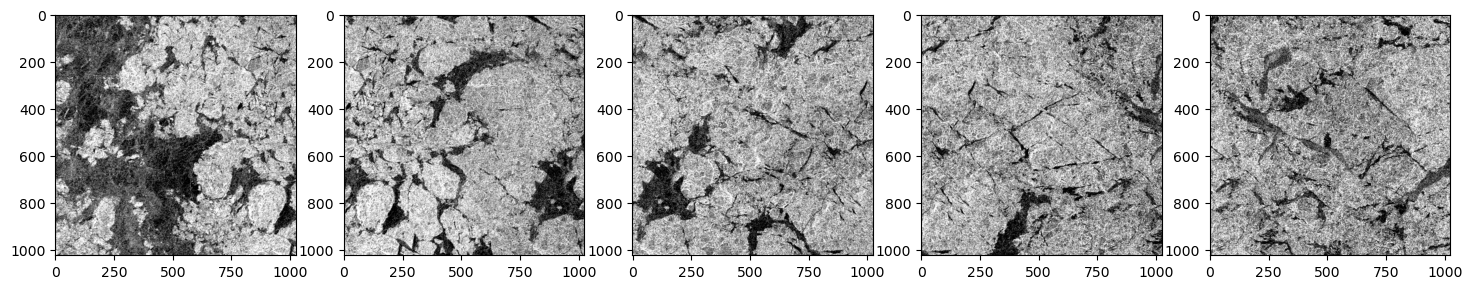

In [10]:
# Plotting the first few windows / patches after filtering
# Now the windows / patches dominated by invalid data (NaNs) have been removed

import matplotlib.pyplot as plt
import numpy as np

n = 5

fig, ax = plt.subplots(1, n, figsize=(18, 6))

for i in range(n):
    ax[i].imshow(HH_patches_filtered[i], cmap='gist_gray', vmin=np.nanpercentile(HH_patches_filtered[i], 2), vmax=np.nanpercentile(HH_patches_filtered[i], 98))

In [11]:
# Getting the corresponding HV windows / patches

HV_patches_filtered = torch.stack(patchify(HV, patch_size=patch_size, step_size=step_size))[valid_patches]

# Adding dimension to stack HH / HV channels
HH_patches_filtered = HH_patches_filtered[:, None]
HV_patches_filtered = HV_patches_filtered[:, None]

# Stacking HH and HV windows / patches along the channel dimension
patches_filtered = torch.cat([HH_patches_filtered, HV_patches_filtered], dim=1)
print(patches_filtered.shape) # N_samples x Channels x Height x Width

torch.Size([156, 2, 1024, 1024])


In [14]:
# Saving to .zarr
import os
import zarr
import numcodecs
from tqdm import tqdm

patch_shape = (2, patch_size, patch_size)
chunk_shape = (2, patch_size // 2, patch_size // 2) # (channels, height, width)
patch_dtype = 'float16' # I typically use float16 because I use mixed precision training (https://docs.pytorch.org/tutorials/recipes/recipes/amp_recipe.html) when I train models, use float32 if you don't plan to use mixed precision training
compressor = numcodecs.Blosc(cname='lz4hc', clevel=5, shuffle=numcodecs.Blosc.SHUFFLE) # using a bit of compression to reduce disk requirements

patches_dir = os.getcwd()
save_path = os.path.join(patches_dir, os.path.basename(zips[0])[:-4])
if not os.path.exists(save_path):
    os.makedirs(save_path)

for i in tqdm(range(len(patches_filtered))):
    patch_archive = zarr.open(os.path.join(save_path, f'{i}.zarr'), mode='w', shape=patch_shape, chunks=chunk_shape, dtype=patch_dtype, compressor=compressor)
    patch_archive[:] = patches_filtered[i].half().numpy() # .half() reduces precision to float16, remove if using float32

100%|██████████| 156/156 [01:03<00:00,  2.44it/s]
